In [1]:
##importing the dependency

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [12]:
##DATA COLLECTION AND PROCESSING 

##loading the data from csv file to pandas dataframe

car_dataset=pd.read_csv('/Users/vedantkalambe/Desktop/python/projects/archive/car data.csv')




In [4]:
##inspecting first five rows of the dataframe
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
##checking the number of rows and columns/ no. of datapoints in entire dataset
car_dataset.shape 

(301, 9)

In [6]:
##getting some information about this dataframe
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [13]:
##checking the number of missing values
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
## this shows that we have 9 columns and none of the value is missing 


In [9]:
##checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [ ]:
##we checked the number of petrol/diesel cars, is it sold by the dealer/individual


##now our dataset contains text in format and usually ml model doesnt work well with alphabets so we will convert this into numerical values 

##petrol-0,diesel-1, cng-2 eg

##this is known as encoding the data necessary bcoz computers better understands number instead of alohabets

In [11]:
##encoding the categorical data

#encoding fuel type column
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)

#encoding for seller type
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}}, inplace=True)

#encoding transmission column:
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}}, inplace=True)


/var/folders/nf/17_trc1d0zvdfjngffj0hj380000gn/T/ipykernel_24662/750534038.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)
/var/folders/nf/17_trc1d0zvdfjngffj0hj380000gn/T/ipykernel_24662/750534038.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}}, inplace=True)
/var/folders/nf/17_trc1d0zvdfjngffj0hj380000gn/T/ipykernel_24662/750534038.py:10: FutureWarning: Downcasting behavior in `

In [13]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [14]:
##splitting the data and target

X=car_dataset.drop(['Car_Name','Selling_Price'],axis=1)
##if you want to drop the column then axis value is 1 and row for 0

Y=car_dataset['Selling_Price']

In [15]:
print(Y)##gives the price of cars

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [16]:
##splitting training and test data
X_train, X_test, Y_train,Y_test=train_test_split(X,Y, test_size=0.1, random_state=2)
##test size 0.1 matlab 10% of the total is test data

In [6]:
##MODEL TRAINING
#loading the linear regression model

lin_reg_model=LinearRegression()

In [20]:
lin_reg_model.fit(X_train,Y_train)

ValueError: could not convert string to float: 'Petrol'

In [19]:
##model evaluation:

#prediction on training data
training_data_prediction=lin_reg_model.predict(X_train)


ValueError: could not convert string to float: 'Petrol'

In [ ]:
#R SQUARED ERROR

error_score=metrics.r2_score(Y_train,training_data_prediction)
print("R squared error: ", error_score)

R squared error:  0.8799451660493707


<function matplotlib.pyplot.show(close=None, block=None)>

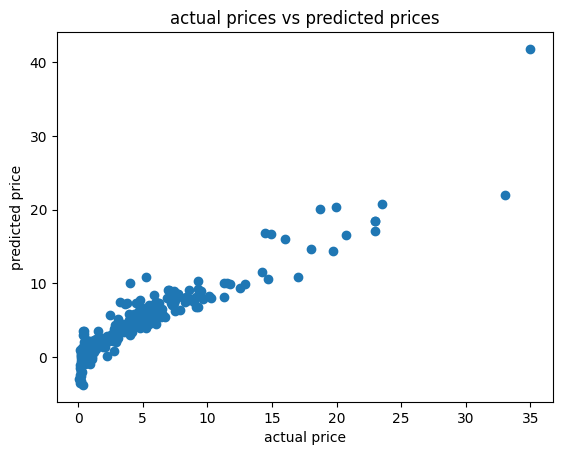

In [ ]:
##visualize the actual prices and predicted prices

plt.scatter(Y_train,training_data_prediction)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual prices vs predicted prices")
plt.show

In [ ]:
##prediction on test data
test_data_prediction=lin_reg_model.predict(X_test)



In [ ]:
#R squared error:
error_score=metrics.r2_score(Y_test, test_data_prediction)
print("R squared error: ", error_score)
  

R squared error:  0.8365766715025327


<function matplotlib.pyplot.show(close=None, block=None)>

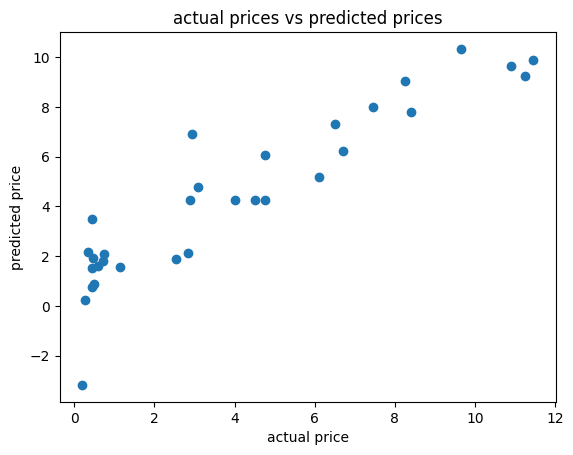

In [ ]:
#visualize the actual prices and predicted prices
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual prices vs predicted prices")
plt.show

In [ ]:
new_car = [[2018, 5.5, 30000, 0, 1, 0, 1]]
lin_reg_model.predict(new_car)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.53872937])

In [ ]:
lin_reg_model.fit(X.values,Y.values)
lin_reg_model.predict(new_car)

array([3.64869559])

In [ ]:
import pickle

pickle.dump(lin_reg_model, open("lin_reg_model.pkl", "wb"))

NameError: name 'lin_reg_model' is not defined

NameError: name 'lin_reg_model' is not defined